In [2]:
# magic command to display matplotlib plots inline within the ipython notebook webpage
%matplotlib inline

# import necessary modules
import pandas as pd, numpy as np, matplotlib.pyplot as plt


In [5]:
df = pd.read_csv('C:/Users/18095/Desktop/PTUA/PTUA2026-main/PTUA2026-main/Lab04/data/summer-travel-gps-full.csv')
df.head()

,lat,lon,date,city,country
0,51.481292,-0.451011,05/14/2014 09:07,West Drayton,United Kingdom
1,51.474005,-0.450999,05/14/2014 09:22,Hounslow,United Kingdom
2,51.478199,-0.446081,05/14/2014 10:51,Hounslow,United Kingdom
3,51.478199,-0.446081,05/14/2014 11:24,Hounslow,United Kingdom
4,51.474146,-0.451562,05/14/2014 11:38,Hounslow,United Kingdom


In [6]:
# Q1: how to get 2 columns from the dataframe (city and country)?
df[['city', 'country']]

,city,country
0,West Drayton,United Kingdom
1,Hounslow,United Kingdom
2,Hounslow,United Kingdom
3,Hounslow,United Kingdom
4,Hounslow,United Kingdom
...,...,...
1754,Munich,Germany
1755,Munich,Germany
1756,Munich,Germany
1757,Munich,Germany


In [8]:
# Q2: how to get the first 5 rows of the "city" column?
df.iloc[:5]['city']

0    West Drayton
1        Hounslow
2        Hounslow
3        Hounslow
4        Hounslow
Name: city, dtype: object

In [9]:
# Q3: how to use .loc to select the third row of the dataframe?
df.loc[2]

lat               51.478199
lon               -0.446081
date       05/14/2014 10:51
city               Hounslow
country      United Kingdom
Name: 2, dtype: object

In [11]:
# Q4: how to use .loc to select the first row in "country" column?
df.loc[0,'country']

'United Kingdom'

In [16]:
# Q5: how to select the first 4 rows of ['city', 'date'] columns?
df.loc[:4,['city','date']]
df.iloc[:4],['city','date']

(         lat       lon              date          city         country
 0  51.481292 -0.451011  05/14/2014 09:07  West Drayton  United Kingdom
 1  51.474005 -0.450999  05/14/2014 09:22      Hounslow  United Kingdom
 2  51.478199 -0.446081  05/14/2014 10:51      Hounslow  United Kingdom
 3  51.478199 -0.446081  05/14/2014 11:24      Hounslow  United Kingdom,
 ['city', 'date'])

In [18]:
# use .iloc for integer position based indexing
# Q6: how to get the value from the row in position 3 and the column in position 2
df.iloc[3,2]

'05/14/2014 11:24'

In [19]:
# Q7: how to use iloc to select every 300th row from a data set
df.iloc[::300]

,lat,lon,date,city,country
0,51.481292,-0.451011,05/14/2014 09:07,West Drayton,United Kingdom
300,41.377091,2.151175,05/20/2014 03:18,Barcelona,Spain
600,50.052338,19.946220,05/31/2014 21:10,Krakow,Poland
900,48.561181,9.059672,06/09/2014 15:12,Tübingen,Germany
1200,41.378301,2.187443,06/17/2014 16:37,Barcelona,Spain
1500,42.208201,20.735993,06/30/2014 08:27,Prizren,Kosovo


In [50]:
df.tail()
df = pd.read_csv('C:/Users/18095/Desktop/PTUA/PTUA2026-main/PTUA2026-main/Lab04/data/summer-travel-gps-simplified.csv')

In [51]:
# Q9: create a Series of true/false, indicating if each "city" row in the column is equal to "Munich"
df['city']=='Munich'

0      False
1      False
2      False
3      False
4      False
       ...  
173    False
174    False
175    False
176    False
177     True
Name: city, Length: 178, dtype: bool

In [71]:
# pandas logical operators are: | for or, & for and, ~ for not
# these must be grouped by using parentheses
# Q10: what cities were visited in spain that were not barcelona? Create a dataframe for it. 
cities_Spain_not_barcelona = df.loc[(df['country'] == 'Spain') & (df['city'] != 'Barcelona'),['city']]
print(result)

           lat        lon              date       city  country
139  44.821164  20.289821  06/21/2014 01:59   Belgrade   Serbia
140  44.820414  20.463465  06/21/2014 18:44   Belgrade   Serbia
141  44.761583  19.577904  06/22/2014 07:58  Slepčević   Serbia
177  48.357110  11.791346  07/09/2014 13:20     Munich  Germany


In [70]:
# Q11: select rows where either the city is munich, or the country is serbia
result = df.loc[(df['city'] == 'Munich') | (df['country'] == 'Serbia')]
print(result)

           lat        lon              date       city  country
139  44.821164  20.289821  06/21/2014 01:59   Belgrade   Serbia
140  44.820414  20.463465  06/21/2014 18:44   Belgrade   Serbia
141  44.761583  19.577904  06/22/2014 07:58  Slepčević   Serbia
177  48.357110  11.791346  07/09/2014 13:20     Munich  Germany


In [55]:
# Q12: how many observations are west of the prime meridian?
df.columns
(df['lon']<0).sum()

np.int64(24)

In [69]:
# Q13: get all rows that contain a city that starts with the letter G
result = df.loc[df['city'].str.startswith('G')]
print(result)

           lat        lon              date         city  country
62   50.273632  18.729429  06/02/2014 06:39      Gliwice   Poland
114  48.282940   8.199630  06/10/2014 13:33       Gutach  Germany
115  48.389029   8.021342  06/10/2014 13:48   Gengenbach  Germany
152  40.187825  20.079303  07/04/2014 17:42  Gjirokastër  Albania


In [75]:
# Q14: how many unique cities and countries in the dataset? 
# Also can you check missing values for the dataframe
df['city'].unique
df['country'].unique
df.isnull().sum()

lat        0
lon        0
date       0
city       0
country    0
dtype: int64

In [79]:
# Q15: group by country name and show the city names in each of the country
df.groupby('country')['city'].apply(list)

country
Albania                                                [Berat, Gjirokastër]
Bosnia and Herzegovina                         [Sarajevo, Sarajevo, Mostar]
Croatia                                           [Ploče, Split, Dubrovnik]
Czech Republic            [Novy Bohumin, Hranice, Prerov, Ústí nad Orlic...
Germany                   [Kümmersbruck, Winkelhaid, Kammerstein, Ellhof...
Greece                    [Kakavia, Dytiki Ellada, Dytiki Ellada, Dytiki...
Kosovo                                                            [Prizren]
Macedonia (FYROM)                                                   [Ohrid]
Montenegro                                                          [Kotor]
Poland                    [Zendek, Silesian Voivodeship, Dabrowa Gornicz...
Portugal                  [Lisbon, Lisbon, Lisbon, Lisbon, Lisbon, Lisbo...
Serbia                                      [Belgrade, Belgrade, Slepčević]
Spain                     [El Prat de Llobregat, Viladecans, Barcelona, ...
Turk

In [80]:
dt = pd.read_csv('C:/Users/18095/Desktop/PTUA/PTUA2026-main/PTUA2026-main/Lab04/data/summer-travel-gps-full.csv', index_col='date', parse_dates=True)
dt.head()

,lat,lon,city,country
date,,,,
2014-05-14 09:07:00,51.481292,-0.451011,West Drayton,United Kingdom
2014-05-14 09:22:00,51.474005,-0.450999,Hounslow,United Kingdom
2014-05-14 10:51:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:24:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:38:00,51.474146,-0.451562,Hounslow,United Kingdom


In [93]:
# Q16: is the timestamp index unique? How can you use code to find it? 
dt.index.is_unique

False

In [94]:
# Q17: drop duplicate index 
dt=dt[~dt.index.duplicated()]

In [101]:
# Q18: create a weekday and a weekend dataframe
type(dt.index)
weekday_dt=dt[dt.index.weekday<5]
print(weekday_dt)
weekend_dt=dt[dt.index.dayofweek>=5]
print(weekend_dt)

                           lat        lon          city         country
date                                                                   
2014-05-14 09:07:00  51.481292  -0.451011  West Drayton  United Kingdom
2014-05-14 09:22:00  51.474005  -0.450999      Hounslow  United Kingdom
2014-05-14 10:51:00  51.478199  -0.446081      Hounslow  United Kingdom
2014-05-14 11:24:00  51.478199  -0.446081      Hounslow  United Kingdom
2014-05-14 11:38:00  51.474146  -0.451562      Hounslow  United Kingdom
...                        ...        ...           ...             ...
2014-07-09 13:13:00  48.356013  11.791710        Munich         Germany
2014-07-09 13:14:00  48.356529  11.792183        Munich         Germany
2014-07-09 13:17:00  48.356285  11.791710        Munich         Germany
2014-07-09 13:18:00  48.355328  11.791710        Munich         Germany
2014-07-09 13:20:00  48.357110  11.791346        Munich         Germany

[1245 rows x 4 columns]
                           lat        l

<Axes: xlabel='date'>

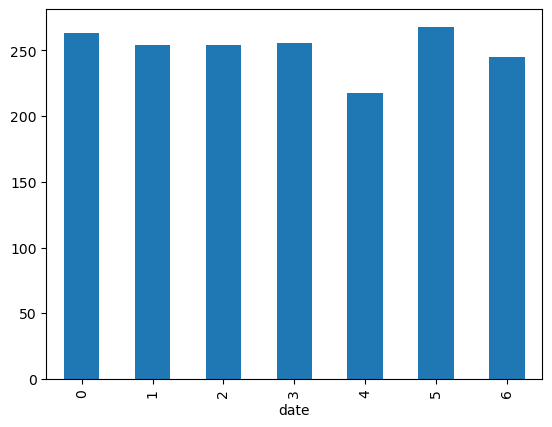

In [102]:
# Q19: calculate and plot the number of observations each day of the week has
obs_by_weekday = dt.index.dayofweek.value_counts().sort_index()
obs_by_weekday.plot(kind='bar')